In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import cmocean as cm
import xgcm
import colorcet as ccm
import gsw

In [2]:
from dask.distributed import Client

In [3]:
c = Client()
c 

/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44216 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:44216/status,
Dashboard: http://127.0.0.1:44216/status,Workers: 8
Total threads: 48,Total memory: 503.20 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39970,Workers: 0
Dashboard: http://127.0.0.1:44216/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40247,Total threads: 6
Dashboard: http://127.0.0.1:40406/status,Memory: 62.90 GiB
Nanny: tcp://127.0.0.1:46497,


In [4]:
from xmitgcm import open_mdsdataset

In [5]:
from utils import *

In [6]:
input_data = "/data/hpcflash/users/josnez/ISOBLJ/ISOBLJ/"

In [7]:
data = dict(dz8={"PATH":"run_z512_dz8/", "expt":{}},
            dz4={"PATH":"run_z512_dz4/", "expt":{}},
            dz2={"PATH":"run_z512_dz2/", "expt":{}})

ISOBLJ = ISOBLJ_Struct(input_data,data=data)

In [8]:
# ISOBLJ.data
ISOBLJ.open_datasets(prefix=['scalars','vels'],endian=">")

expt c120m_Td05_vshift48_dz2 has not run
expt c20m_Td05_vshift48_dz2 has not run
expt c120m_Td01_vshift48_dz2 has not run
expt c120m_Td1_vshift48_dz2 has not run
expt c120m_Td2_vshift48_dz2 has not run
expt c20m_Td01_vshift48_dz2 has not run
expt c60m_Td05_vshift48_dz2 has not run
expt c40m_Td05_vshift48_dz2 has not run
expt c60m_Td2_vshift48_dz2 has not run
expt c20m_Td2_vshift48_dz2 has not run
expt c20m_Td1_vshift48_dz2 has not run
expt c60m_Td01_vshift48_dz2 has not run
expt c40m_Td2_vshift48_dz2 has not run
expt c60m_Td1_vshift48_dz2 has not run
expt c40m_Td1_vshift48_dz2 has not run
expt c40m_Td01_vshift48_dz2 has not run


In [9]:
ISOBLJ.data['dz8']['expt'].pop("c80m_Td2_vshift8_ryan_dz8")
ISOBLJ.data['dz4']['expt'].pop("c80m_Td2_vshift16_ryan_dz4")

{'exec': True,
 'dims': {'nx': np.float64(60.0),
  'ny': np.float64(160.0),
  'nz': np.float64(128.0),
  'dx': np.float64(60.0),
  'dy': np.float64(60.0),
  'dz': np.float64(4.0)},
 'timestep': array(4.),
 'data': <xarray.Dataset> Size: 5GB
 Dimensions:   (XC: 60, YC: 160, XG: 60, YG: 160, Z: 128, Zp1: 129, Zu: 128,
                Zl: 128, time: 180)
 Coordinates: (12/34)
   * XC        (XC) float32 240B 0.03 0.09 0.15 0.21 0.27 ... 3.39 3.45 3.51 3.57
   * YC        (YC) float32 640B 0.03 0.09 0.15 0.21 0.27 ... 9.39 9.45 9.51 9.57
   * XG        (XG) float32 240B 0.0 0.06 0.12 0.18 0.24 ... 3.36 3.42 3.48 3.54
   * YG        (YG) float32 640B 0.0 0.06 0.12 0.18 0.24 ... 9.36 9.42 9.48 9.54
   * Z         (Z) >f4 512B -2.0 -6.0 -10.0 -14.0 ... -498.0 -502.0 -506.0 -510.0
   * Zp1       (Zp1) >f4 516B 0.0 -4.0 -8.0 -12.0 ... -500.0 -504.0 -508.0 -512.0
     ...        ...
     dxF       (YC, XC) >f4 38kB dask.array<chunksize=(160, 60), meta=np.ndarray>
     rhoRef    (Z) >f4 512B dask

In [10]:
temp = ISOBLJ.get_variable("THETA")
Wvel = ISOBLJ.get_variable("WVEL")
salt = ISOBLJ.get_variable("SALT")

In [11]:
def VAR_withBL_TopZ(ds,hfacc=None,hfacc_var="hFacC",var='THETA',out_name="Tf"):
    ds_return=[]
    if not hfacc:
        hfacc=ds
    for dvar in ds.data_vars:
        # print(dvar)
        data = ds.reset_coords(drop=True)[dvar]
        dz = int(dvar.split("dz")[-1])
        z_coord = "Z_dz{0}".format(dz)
        hfacc_name = dvar.replace(var,hfacc_var)
        #This only works for a constant dz
        drK0 = hfacc[hfacc_name].isel({z_coord:0}) * dz
        drK1 = (1 - hfacc[hfacc_name].isel({z_coord:0})) * dz
        recip_drLoc = 1/ ( drK0 + drK1 )

        tvar = (data.isel({z_coord:0}) * drK0 
              + data.isel({z_coord:1}) * drK1)#.compute()

        weighted_var = tvar*recip_drLoc
        ds_return.append(weighted_var.rename(dvar.replace(var,out_name)))
        # break
        
    return xr.merge(ds_return)

def coord_dtype(ds):
    for coord in ds.coords:
        ds[coord]= ds[coord].astype(np.float64)
    return ds

def compute_freezing(ds,p=300):
    ds_return=[]
    for dvar in ds.data_vars:
        freezing = gsw.CT_freezing(ds[dvar],p,0)
        ds_return.append(freezing)
    return xr.merge(ds_return)

In [12]:
temp = coord_dtype(temp.astype(float)).isel(time=-1)
Wvel = coord_dtype(Wvel.astype(float)).isel(time=-1)
salt = coord_dtype(salt.astype(float)).isel(time=-1)

In [13]:
salt_shifted_ud = shifted_dataset(salt,method = "ud")
salt_bl = VAR_withBL_TopZ(salt_shifted_ud, var='SALT',out_name='T_freezing')

In [14]:
T_freezing = compute_freezing(salt_bl)

In [15]:
T_freezing.to_netcdf("freezing_temperatures.nc")

/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 74.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [16]:

T_freezing=xr.open_dataset("freezing_temperatures.nc")
T_freezing =T_freezing.drop_vars([coord for coord in T_freezing.coords if "hFacC" in coord])

T_ref = gsw.CT_freezing(34.5,300,0)
T_ref

np.float64(-2.1089700790310886)

In [17]:
grids = ISOBLJ._get_grid()

In [18]:
wT=[]
T_anom=[]
w_test=[]
for var in np.sort(Wvel.data_vars):
    print(var)
    expt=var.split("WVEL_")[1]
    grid = grids[expt]
    dz = int(var.split("dz")[-1])
    Wvel_interp = grid.interp(Wvel[var].rename({"Zl_dz{0}".format(dz):"Zl"}),'Z').rename({"Z":"Z_dz{0}".format(dz)})
    temp_var = temp[var.replace("WVEL","THETA")] - T_ref #- T_freezing[var.replace("WVEL","T_freezing")]
    T_anom.append(temp_var.rename("Tanom_"+expt))
    wT.append((Wvel_interp * temp_var).rename("wT_"+expt))
    w_test.append(Wvel_interp)

wT_ds=xr.merge(wT)
w_test_ds=xr.merge(w_test)
T_anom_ds=xr.merge(T_anom)

WVEL_c0m_Td01_vshift12_dz8
WVEL_c0m_Td01_vshift24_dz4
WVEL_c0m_Td01_vshift48_dz2
WVEL_c0m_Td05_vshift12_dz8
WVEL_c0m_Td05_vshift24_dz4
WVEL_c0m_Td05_vshift48_dz2
WVEL_c0m_Td1_vshift12_dz8
WVEL_c0m_Td1_vshift24_dz4
WVEL_c0m_Td1_vshift48_dz2
WVEL_c0m_Td2_vshift12_dz8
WVEL_c0m_Td2_vshift24_dz4
WVEL_c0m_Td2_vshift48_dz2
WVEL_c120m_Td01_vshift12_dz8
WVEL_c120m_Td01_vshift24_dz4
WVEL_c120m_Td05_vshift12_dz8
WVEL_c120m_Td05_vshift24_dz4
WVEL_c120m_Td1_vshift12_dz8
WVEL_c120m_Td1_vshift24_dz4
WVEL_c120m_Td2_vshift12_dz8
WVEL_c120m_Td2_vshift24_dz4
WVEL_c160m_Td01_vshift12_dz8
WVEL_c160m_Td01_vshift24_dz4
WVEL_c160m_Td01_vshift48_dz2
WVEL_c160m_Td05_vshift12_dz8
WVEL_c160m_Td05_vshift24_dz4
WVEL_c160m_Td05_vshift48_dz2
WVEL_c160m_Td1_vshift12_dz8
WVEL_c160m_Td1_vshift24_dz4
WVEL_c160m_Td1_vshift48_dz2
WVEL_c160m_Td2_vshift12_dz8
WVEL_c160m_Td2_vshift24_dz4
WVEL_c160m_Td2_vshift48_dz2
WVEL_c20m_Td01_vshift12_dz8
WVEL_c20m_Td01_vshift24_dz4
WVEL_c20m_Td05_vshift12_dz8
WVEL_c20m_Td05_vshift24_dz4


In [19]:
wT_ds_shift = shifted_dataset(wT_ds,method = "du")

w_test_ds_shift = shifted_dataset(w_test_ds,method = "du")

temp_shift = shifted_dataset(temp,method = "du")

Tanom_shift = shifted_dataset(T_anom_ds,method = "du")

In [20]:
from matplotlib.collections import PolyCollection
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

def plot_hfacc_surf_shifted(ax,ds,dz,z_shift=512):
    
    x_ = (ds.YC - 60/2000)
    x_ = np.append(np.roll(np.repeat(x_, 2),-1)[:-1], x_[-1]+60/2000)
    Hfacc_shifted = shifted_computations(ds.hFacC,method="du").mean("XC").T

    z_ = (abs(((np.sum( 1 - Hfacc_shifted ,axis=0))  * dz) + z_shift) + z_shift)
    z_ = np.repeat(z_, 2) 

    x = np.append(np.hstack((0 ,x_)),x_[-1]+120/2000)
    if z_shift==-512:
        z = np.append(np.hstack((0 ,z_)),0)
    else:
        z = np.append(np.hstack((z_shift ,z_)),z_shift)

    verts = [np.array(list(zip(x, z)))]
    # print(verts)
    
    poly = PolyCollection(verts, alpha=1, zorder=1,
                          facecolors=[[0.9, 0.9, 0.9]])
    ax.add_collection(poly)

wT_c80m_Td2_vshift48_dz2
wT_c80m_Td2_vshift24_dz4
wT_c80m_Td2_vshift12_dz8
wT_c60m_Td2_vshift24_dz4
wT_c60m_Td2_vshift12_dz8
wT_c40m_Td2_vshift24_dz4
wT_c40m_Td2_vshift12_dz8
wT_c20m_Td2_vshift24_dz4
wT_c20m_Td2_vshift12_dz8
wT_c160m_Td2_vshift48_dz2
wT_c160m_Td2_vshift24_dz4
wT_c160m_Td2_vshift12_dz8
wT_c120m_Td2_vshift24_dz4
wT_c120m_Td2_vshift12_dz8
wT_c0m_Td2_vshift48_dz2
wT_c0m_Td2_vshift24_dz4
wT_c0m_Td2_vshift12_dz8


/tmp/ipykernel_17360/2254990983.py:186: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  iax2.set_yticklabels(ticklabels)


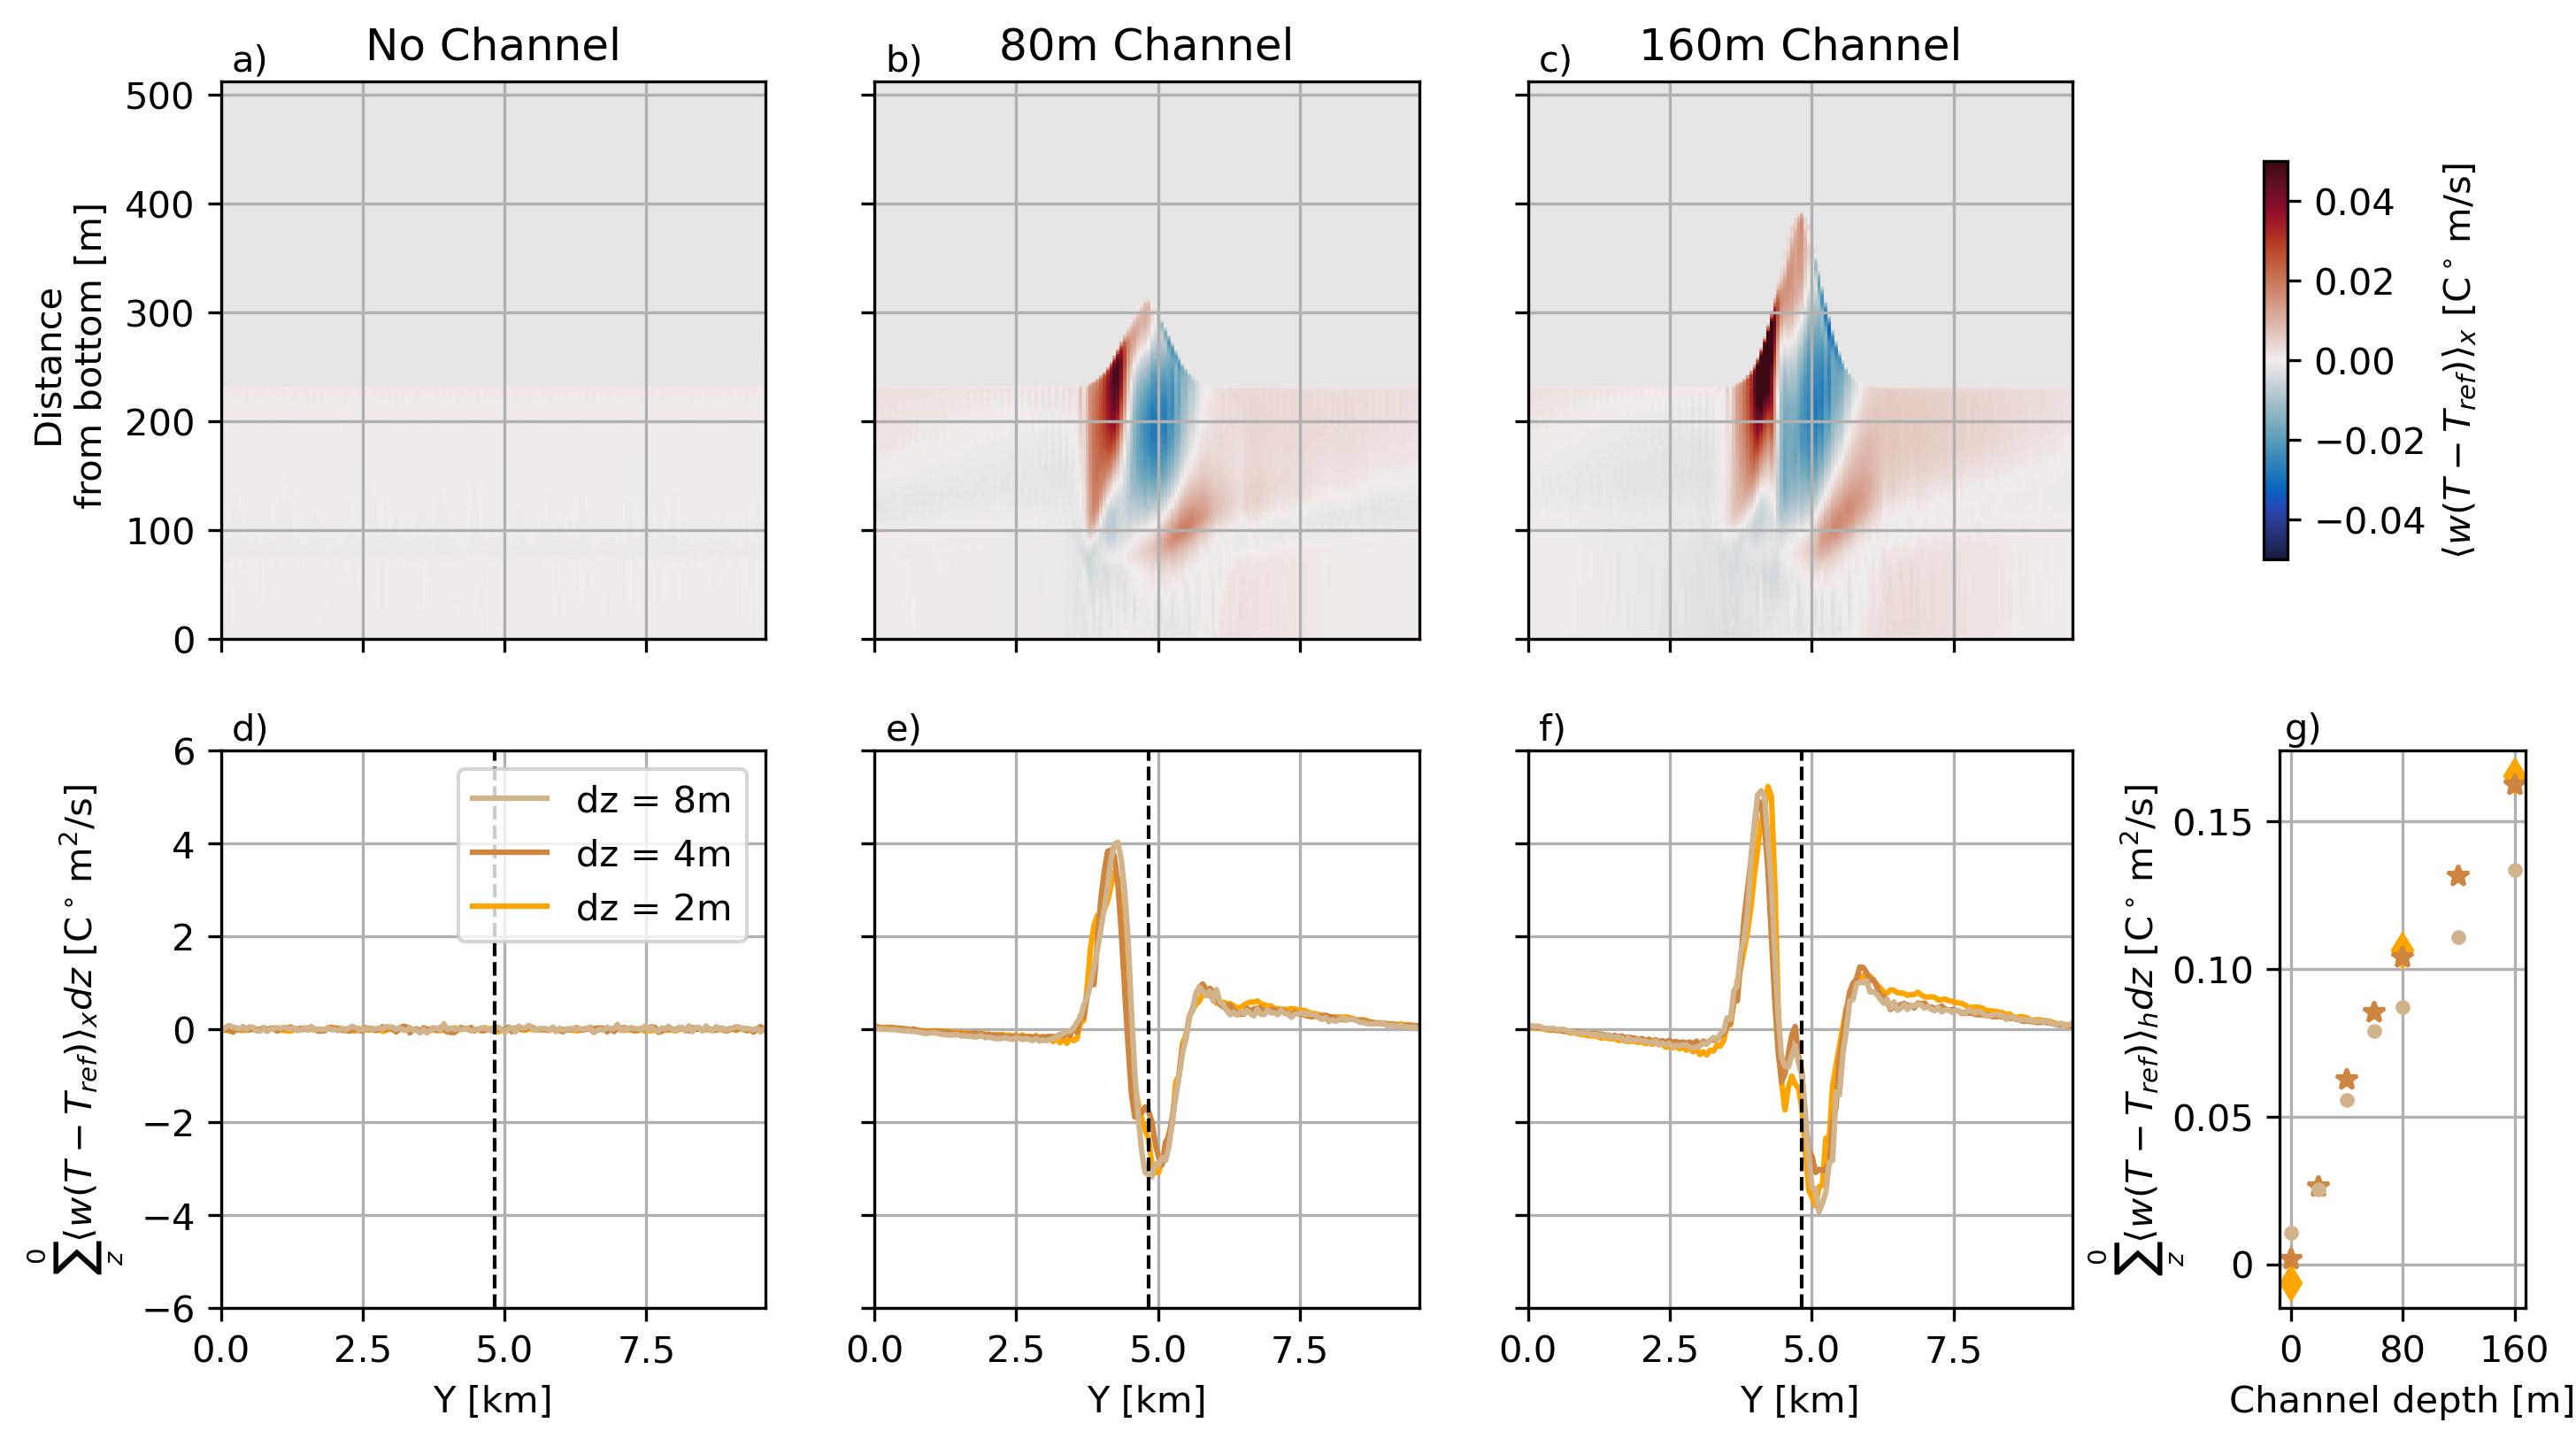

In [21]:
# ADVx_Vm_shift.ADVx_Vm_c120m_Td2_vshift24_dz4
# ADVy_Vm_shift.ADVy_Vm_c120m_Td2_vshift24_dz4
# ADVrE_Vm_shift.ADVrE_Vm_c120m_Td2_vshift24_dz4

fig,ax = plt.subplots(2,3,figsize=(9,6),dpi=300)

kwargs={ 
    "cmap":cm.cm.balance,
    "vmin":-5e-2,
    "vmax":5e-2,
    "add_colorbar":False,
    "rasterized":True
}

kwargs_ustar={ 
    "cmap":cm.cm.solar,
    "vmin":0.01,
    "vmax":0.05,
}


cbar1 = wT_ds_shift.wT_c0m_Td2_vshift48_dz2.mean(("XC")).plot(x="YC",ax=ax[0,0],**kwargs)

wT_ds_shift.wT_c80m_Td2_vshift48_dz2.mean(("XC")).plot(x="YC",ax=ax[0,1],**kwargs)

wT_ds_shift.wT_c160m_Td2_vshift48_dz2.mean(("XC")).plot(x="YC",ax=ax[0,2],**kwargs)


grid = grids["c80m_Td2_vshift48_dz2"]


plot_hfacc_surf_shifted(ax[0,0],
                                wT_ds_shift.hFacC_c0m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"Z_dz2":"Z"}),
                                2,z_shift=-512)
plot_hfacc_surf_shifted(ax[0,1],
                                wT_ds_shift.hFacC_c80m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"Z_dz2":"Z"}),
                                2,z_shift=-512)
plot_hfacc_surf_shifted(ax[0,2],
                                wT_ds_shift.hFacC_c160m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"Z_dz2":"Z"}),
                                2,z_shift=-512)


# z_dz2 = extract_channel_coords(VVEL["hFacS_c80m_Td2_vshift48_dz2"].rename({"hFacS_c80m_Td2_vshift48_dz2":"hFacC"}),dz=2)
# cbar_ustar = plot_channel_surface_property(ax[0,0], z_dz2-482, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)
# plot_channel_surface_property(ax[0,1], z_dz2-482, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)
# plot_channel_surface_property(ax[0,2], z_dz2-482, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)
# plot_channel_surface_property(ax[0,3], z_dz2-482, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)


########################################################################
########################################################################
########################################################################

(2*wT_ds_shift.wT_c0m_Td2_vshift48_dz2.mean(("XC")).sum("Z_dz2")).plot(x="YC",ax=ax[1,0],color="orange")
(4*wT_ds_shift.wT_c0m_Td2_vshift24_dz4.mean(("XC")).sum("Z_dz4")).plot(x="YC",ax=ax[1,0],color="peru")
(8*wT_ds_shift.wT_c0m_Td2_vshift12_dz8.mean(("XC")).sum("Z_dz8")).plot(x="YC",ax=ax[1,0],color="tan")

(2*wT_ds_shift.wT_c80m_Td2_vshift48_dz2.mean(("XC")).sum("Z_dz2")).plot(x="YC",ax=ax[1,1],color="orange")
(4*wT_ds_shift.wT_c80m_Td2_vshift24_dz4.mean(("XC")).sum("Z_dz4")).plot(x="YC",ax=ax[1,1],color="peru")
(8*wT_ds_shift.wT_c80m_Td2_vshift12_dz8.mean(("XC")).sum("Z_dz8")).plot(x="YC",ax=ax[1,1],color="tan")

(2*wT_ds_shift.wT_c160m_Td2_vshift48_dz2.mean(("XC")).sum("Z_dz2")).plot(x="YC",ax=ax[1,2],color="orange")
(4*wT_ds_shift.wT_c160m_Td2_vshift24_dz4.mean(("XC")).sum("Z_dz4")).plot(x="YC",ax=ax[1,2],color="peru")
(8*wT_ds_shift.wT_c160m_Td2_vshift12_dz8.mean(("XC")).sum("Z_dz8")).plot(x="YC",ax=ax[1,2],color="tan")

# (udvdx).mean("XC").plot(x="YG",ax=ax[1,0],color="orange")

# (vdvdy).mean("XC").plot(x="YG",ax=ax[1,1],color="orange")

# (wdvdz).mean("XC").plot(x="YG",ax=ax[1,2],color="orange")

# adv1 = 5*(udvdx + vdvdy + wdvdz).mean("XC")

# adv1.plot(x="YG",ax=ax[1,3],color="orange")


# for a in ax[1,:]:
#     a.plot(np.ones(2)*ADVx_Vm_surf.YG[80].values,[-0.01,0.01],linestyle='--',color='k',linewidth=1)

# [a.set_ylabel("") for a in ax[1,:]]
# [a.set_xlabel("") for a in ax[1,:]]
[a.set_ylim(-6,6) for a in ax[1,:]]

# [a.set_title("") for a in ax[1,:]]


# ax[1,3].plot(0,0,color='orange',label="dz = 2m",linestyle='-')
# ax[1,3].legend()

########################################################################
########################################################################
########################################################################

ticklocations = [-512,-412,-312,-212,-112,-12]
[a.yaxis.set_ticks(ticklocations) for a in ax[0,:]]
ticklabels = [0,100,200,300,400,500]
[a.set_yticklabels(ticklabels) for a in ax[0,:]]

[a.yaxis.set_ticklabels([]) for a in ax[:,1:].ravel()]
[a.xaxis.set_ticklabels([]) for a in ax[0,:]]

[a.set_ylabel("") for a in ax.ravel()]
[a.set_xlabel("") for a in ax.ravel()]
[a.grid() for a in ax.ravel()]
[a.set_xlim(0,9.6) for a in ax.ravel()]

[a.set_title("") for a in ax.ravel()]

ax[0,0].set_ylabel("Distance \n from bottom [m]")
[a.set_xlabel("Y [km]") for a in ax[1,:]]
ax[1,0].set_ylabel(r"$\sum_z^0\left<w(T-T_{ref})\right>_{x}dz$ [C$^\circ\,\mathrm{m^2/s}$]")

# ax[0,0].set_ylim(0,9.6)

ax[0,0].text(0.02, 1.02, "a)", fontsize=10, transform=ax[0,0].transAxes)
ax[0,1].text(0.02, 1.02, "b)", fontsize=10, transform=ax[0,1].transAxes)
ax[0,2].text(0.02, 1.02, "c)", fontsize=10, transform=ax[0,2].transAxes)
ax[1,0].text(0.02, 1.02, "d)", fontsize=10, transform=ax[1,0].transAxes)
ax[1,1].text(0.02, 1.02, "e)", fontsize=10, transform=ax[1,1].transAxes)
ax[1,2].text(0.02, 1.02, "f)", fontsize=10, transform=ax[1,2].transAxes)

ax[0,0].set_title("No Channel")
ax[0,1].set_title("80m Channel")
ax[0,2].set_title("160m Channel")

cbar_ax = fig.add_axes([0.98, 0.58, 0.01, 0.25])
fig.colorbar(cbar1, cax =cbar_ax)
cbar_ax.set_ylabel(r"$\left<w(T-T_{ref})\right>_{x}$ [C$^\circ\,\mathrm{m/s}$]")
cbar_ax.yaxis.set_tick_params(labelsize=10)

ax[1,0].plot(0,0,color='tan',label="dz = 8m",linestyle='-')
ax[1,0].plot(0,0,color='peru',label="dz = 4m",linestyle='-')
ax[1,0].plot(0,0,color='orange',label="dz = 2m",linestyle='-')
ax[1,0].legend()

for a in ax[0,:]:
    a.plot(np.ones(2)*wT_ds_shift.YC[80].values,[0,512],linestyle='--',color='k',linewidth=1)

for a in ax[1,:]:
    a.plot(np.ones(2)*wT_ds_shift.YC[80].values,[-6,6],linestyle='--',color='k',linewidth=1)


iax2 = ax[1,2].inset_axes([1.38, 0, .452, 1])
for var in np.flip(wT_ds_shift.data_vars):
    if "ryan" in var:
        continue
    
    if "dz8" in var:
        color="tan"
        marker="."
    elif "dz4" in var:
        color="peru"
        marker="*"
    elif "dz2" in var:
        color="orange"
        marker="d"
        
    if "c80m" in var:
        linestyle="-"
    elif "c160m" in var:
        linestyle="--"
    elif "c0m" in var:
        linestyle="-."
    
##### Melt rate vs Channel #####

    cond = ("vshift12_dz8" in var or "vshift24_dz4" in var or "vshift48_dz2" in var)
    
    if "Td2" in var and cond:
        print(var)
        channel = int(var.split("_c")[1].split("m_")[0]) 
        dz = int(var.split("dz")[-1])
        Melt = wT_ds_shift[var].mean(("XC","YC")).sum() * dz
        # Melt_std = wT_ds_shift[var].std(("XC")).sum()
        iax2.plot(channel, Melt, marker=marker, color=color)
        # iax2.errorbar(channel , Melt,  Melt_std, linestyle='None' ,color=color, fmt='o', linewidth=1, capsize=6)


iax2.set_ylabel(r"$\sum_z^0\left<w(T-T_{ref})\right>_{h}dz$ [C$^\circ\,\mathrm{m^2/s}$]",labelpad=-4)
# iax2.yaxis.label.set_position((0.1, 0.5))
iax2.set_xlabel("Channel depth [m]")
iax2.grid()

iax2.xaxis.set_ticks([0,80,160])
ticklabels = ["0","0","0.05","0.10","0.15"]
iax2.set_yticklabels(ticklabels)
iax2.text(0.02, 1.02, "g)", fontsize=10, transform=iax2.transAxes)

plt.savefig('./figures/Fig_12_wT.pdf', dpi=300, bbox_inches='tight')

# Slope

wT_c80m_Td2_vshift8_dz8
wT_c80m_Td2_vshift8_dz4
wT_c80m_Td2_vshift64_dz2
wT_c80m_Td2_vshift4_dz8
wT_c80m_Td2_vshift48_visc_dz2
wT_c80m_Td2_vshift48_dz2
wT_c80m_Td2_vshift32_dz4
wT_c80m_Td2_vshift32_dz2
wT_c80m_Td2_vshift24_dz4
wT_c80m_Td2_vshift16_dz8
wT_c80m_Td2_vshift16_dz4
wT_c80m_Td2_vshift16_dz2
wT_c80m_Td2_vshift12_dz8


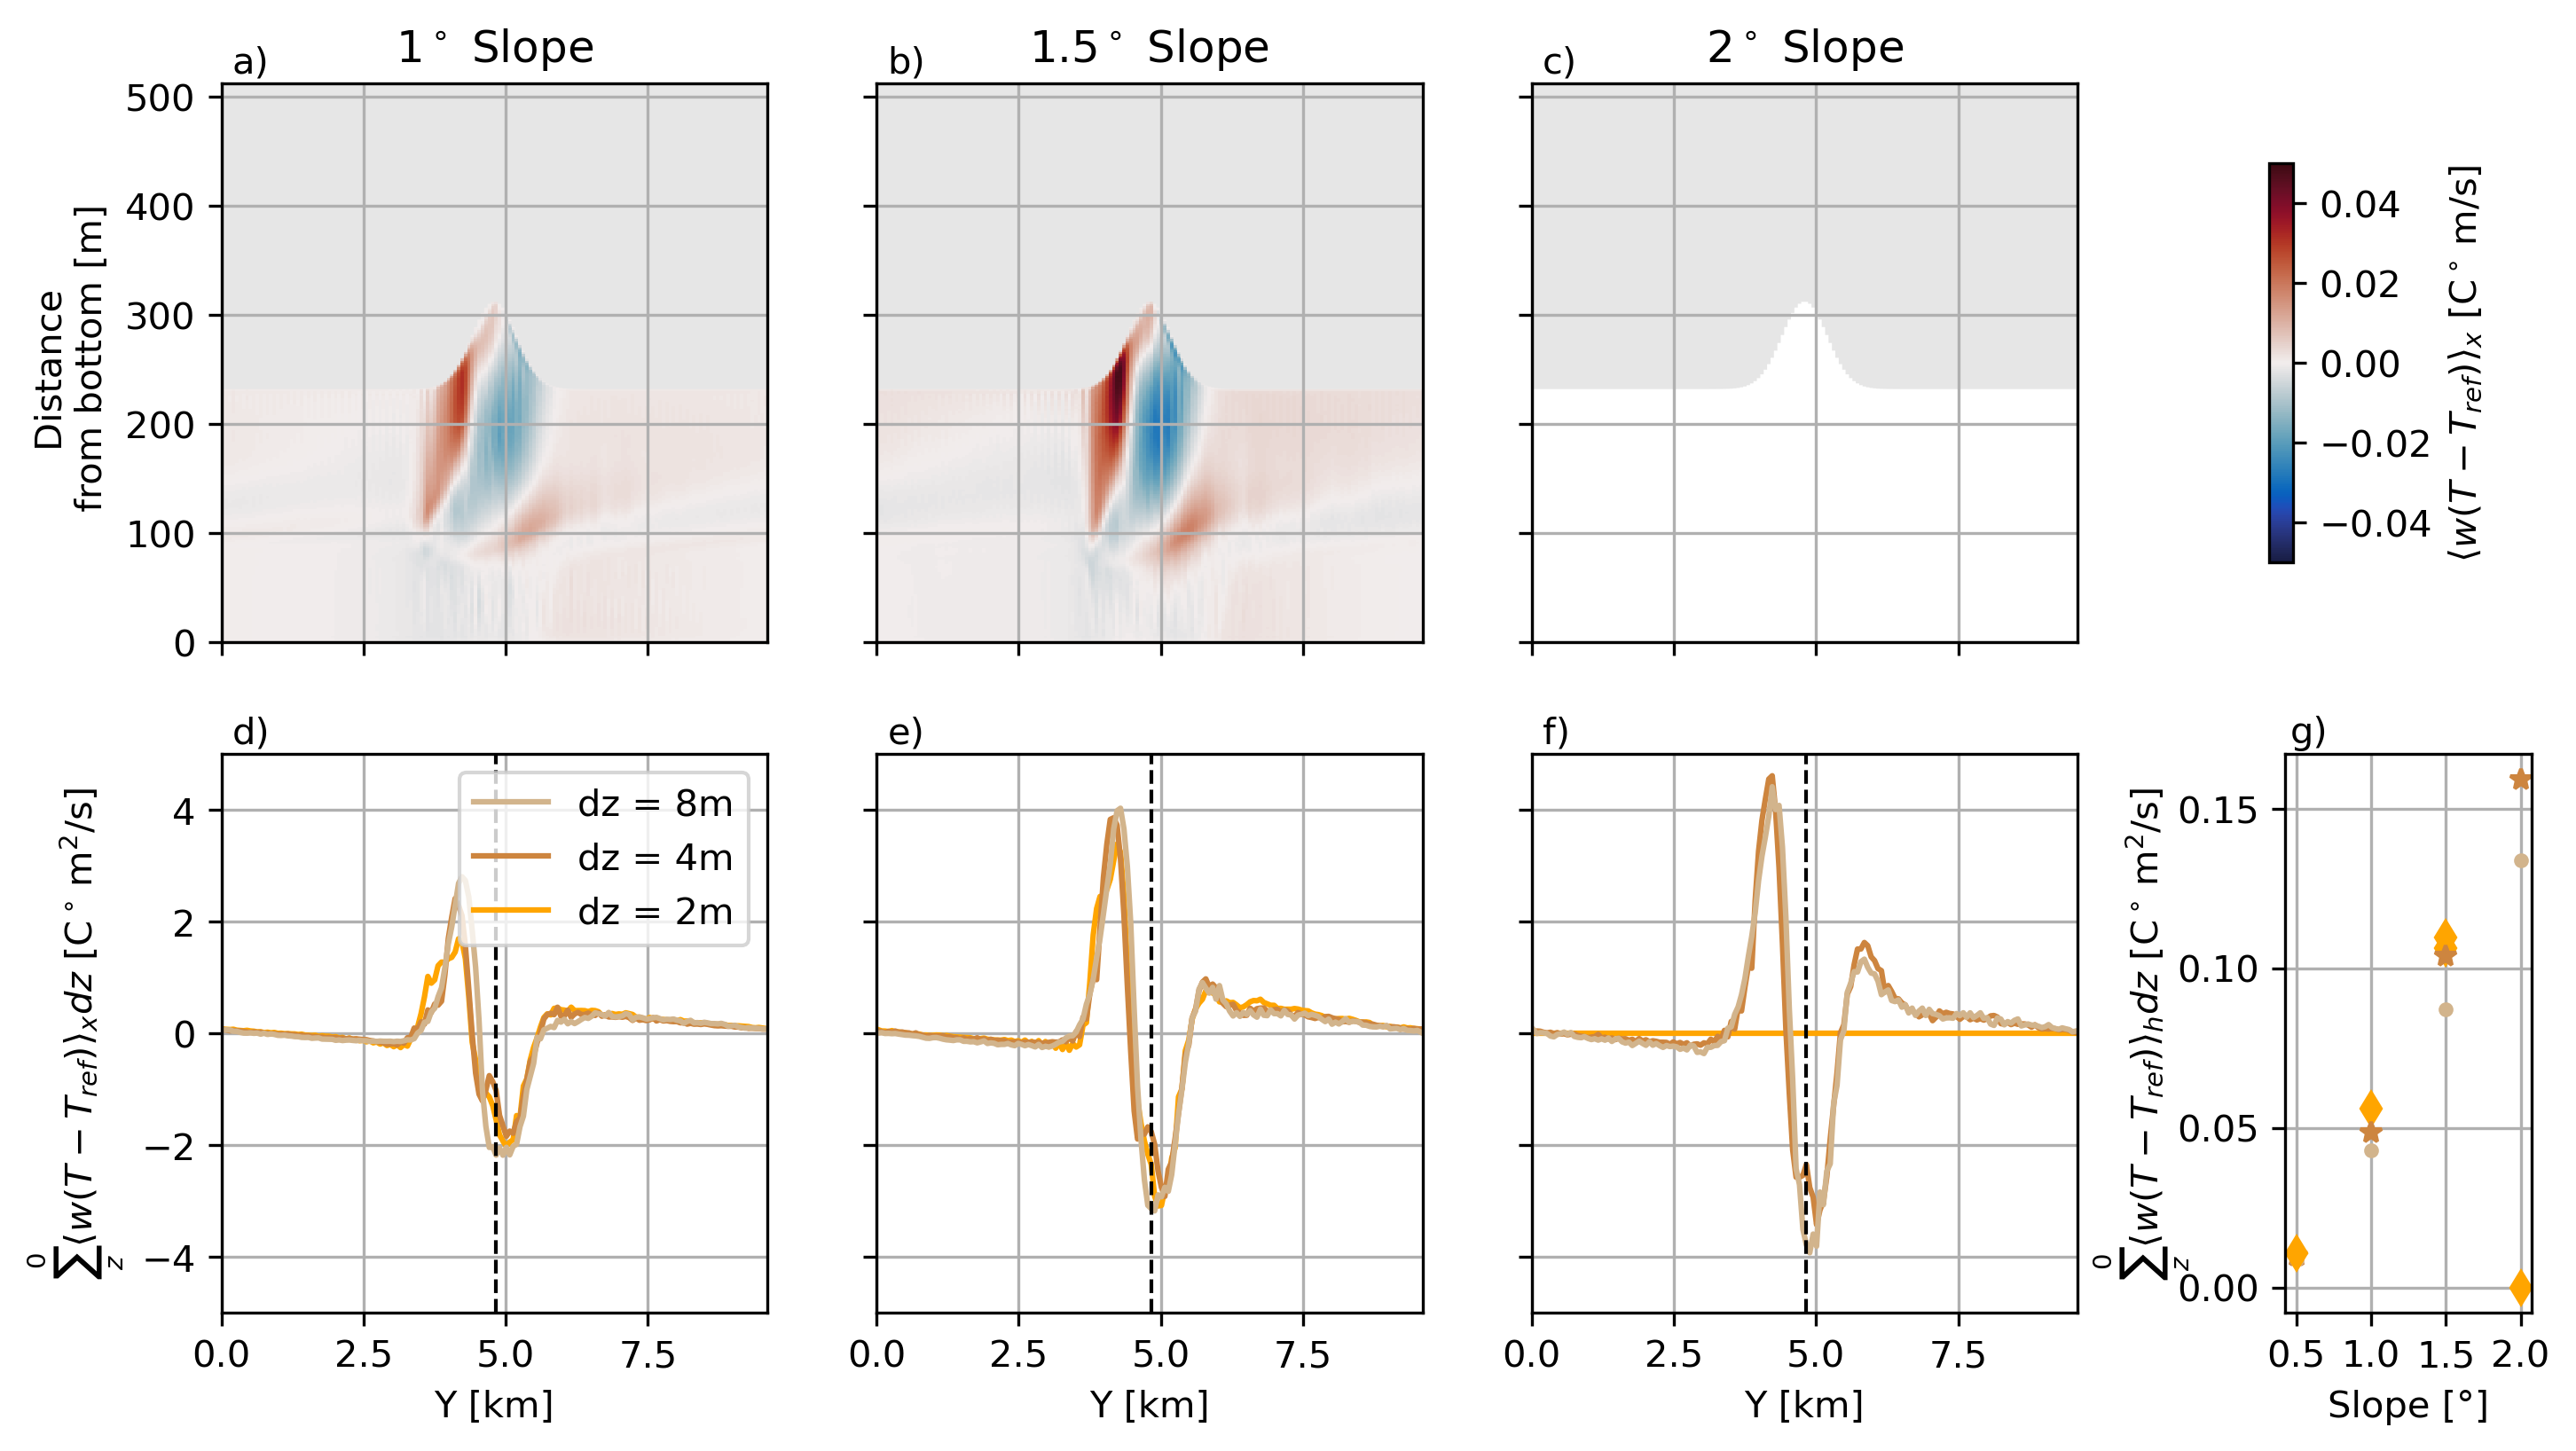

In [22]:
# ADVx_Vm_shift.ADVx_Vm_c120m_Td2_vshift24_dz4
# ADVy_Vm_shift.ADVy_Vm_c120m_Td2_vshift24_dz4
# ADVrE_Vm_shift.ADVrE_Vm_c120m_Td2_vshift24_dz4

fig,ax = plt.subplots(2,3,figsize=(9,6),dpi=300)

kwargs={ 
    "cmap":cm.cm.balance,
    "vmin":-5e-2,
    "vmax":5e-2,
    "add_colorbar":False,
    "rasterized":True
}

kwargs_ustar={ 
    "cmap":cm.cm.solar,
    "vmin":0.01,
    "vmax":0.05,
}


cbar1 = wT_ds_shift.wT_c80m_Td2_vshift32_dz2.mean(("XC")).plot(x="YC",ax=ax[0,0],**kwargs)

wT_ds_shift.wT_c80m_Td2_vshift48_dz2.mean(("XC")).plot(x="YC",ax=ax[0,1],**kwargs)

wT_ds_shift.wT_c80m_Td2_vshift64_dz2.mean(("XC")).plot(x="YC",ax=ax[0,2],**kwargs)


grid = grids["c80m_Td2_vshift48_dz2"]


plot_hfacc_surf_shifted(ax[0,0],
                                wT_ds_shift.hFacC_c80m_Td2_vshift32_dz2.to_dataset(name="hFacC").rename({"Z_dz2":"Z"}),
                                2,z_shift=-512)
plot_hfacc_surf_shifted(ax[0,1],
                                wT_ds_shift.hFacC_c80m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"Z_dz2":"Z"}),
                                2,z_shift=-512)
plot_hfacc_surf_shifted(ax[0,2],
                                wT_ds_shift.hFacC_c80m_Td2_vshift64_dz2.to_dataset(name="hFacC").rename({"Z_dz2":"Z"}),
                                2,z_shift=-512)


# z_dz2 = extract_channel_coords(VVEL["hFacS_c80m_Td2_vshift48_dz2"].rename({"hFacS_c80m_Td2_vshift48_dz2":"hFacC"}),dz=2)
# cbar_ustar = plot_channel_surface_property(ax[0,0], z_dz2-482, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)
# plot_channel_surface_property(ax[0,1], z_dz2-482, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)
# plot_channel_surface_property(ax[0,2], z_dz2-482, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)
# plot_channel_surface_property(ax[0,3], z_dz2-482, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)


########################################################################
########################################################################
########################################################################

(2*wT_ds_shift.wT_c80m_Td2_vshift32_dz2.mean(("XC")).sum("Z_dz2")).plot(x="YC",ax=ax[1,0],color="orange")
(4*wT_ds_shift.wT_c80m_Td2_vshift16_dz4.mean(("XC")).sum("Z_dz4")).plot(x="YC",ax=ax[1,0],color="peru")
(8*wT_ds_shift.wT_c80m_Td2_vshift8_dz8.mean(("XC")).sum("Z_dz8")).plot(x="YC",ax=ax[1,0],color="tan")

(2*wT_ds_shift.wT_c80m_Td2_vshift48_dz2.mean(("XC")).sum("Z_dz2")).plot(x="YC",ax=ax[1,1],color="orange")
(4*wT_ds_shift.wT_c80m_Td2_vshift24_dz4.mean(("XC")).sum("Z_dz4")).plot(x="YC",ax=ax[1,1],color="peru")
(8*wT_ds_shift.wT_c80m_Td2_vshift12_dz8.mean(("XC")).sum("Z_dz8")).plot(x="YC",ax=ax[1,1],color="tan")

(2*wT_ds_shift.wT_c80m_Td2_vshift64_dz2.mean(("XC")).sum("Z_dz2")).plot(x="YC",ax=ax[1,2],color="orange")
(4*wT_ds_shift.wT_c80m_Td2_vshift32_dz4.mean(("XC")).sum("Z_dz4")).plot(x="YC",ax=ax[1,2],color="peru")
(8*wT_ds_shift.wT_c80m_Td2_vshift16_dz8.mean(("XC")).sum("Z_dz8")).plot(x="YC",ax=ax[1,2],color="tan")

# (udvdx).mean("XC").plot(x="YG",ax=ax[1,0],color="orange")

# (vdvdy).mean("XC").plot(x="YG",ax=ax[1,1],color="orange")

# (wdvdz).mean("XC").plot(x="YG",ax=ax[1,2],color="orange")

# adv1 = 5*(udvdx + vdvdy + wdvdz).mean("XC")

# adv1.plot(x="YG",ax=ax[1,3],color="orange")


# for a in ax[1,:]:
#     a.plot(np.ones(2)*ADVx_Vm_surf.YG[80].values,[-0.01,0.01],linestyle='--',color='k',linewidth=1)

# [a.set_ylabel("") for a in ax[1,:]]
# [a.set_xlabel("") for a in ax[1,:]]
[a.set_ylim(-5,5) for a in ax[1,:]]

# [a.set_title("") for a in ax[1,:]]


# ax[1,3].plot(0,0,color='orange',label="dz = 2m",linestyle='-')
# ax[1,3].legend()

########################################################################
########################################################################
########################################################################

ticklocations = [-512,-412,-312,-212,-112,-12]
[a.yaxis.set_ticks(ticklocations) for a in ax[0,:]]
ticklabels = [0,100,200,300,400,500]
[a.set_yticklabels(ticklabels) for a in ax[0,:]]

[a.yaxis.set_ticklabels([]) for a in ax[:,1:].ravel()]
[a.xaxis.set_ticklabels([]) for a in ax[0,:]]

[a.set_ylabel("") for a in ax.ravel()]
[a.set_xlabel("") for a in ax.ravel()]
[a.set_xlim(0,9.6) for a in ax.ravel()]
[a.grid() for a in ax.ravel()]

[a.set_title("") for a in ax.ravel()]

ax[0,0].set_ylabel("Distance \n from bottom [m]")
[a.set_xlabel("Y [km]") for a in ax[1,:]]
ax[1,0].set_ylabel(r"$\sum_z^0\left<w(T-T_{ref})\right>_{x}dz$ [C$^\circ\,\mathrm{m^2/s}$]")

ax[0,0].set_title(r"1$^\circ$ Slope")
ax[0,1].set_title(r"1.5$^\circ$ Slope")
ax[0,2].set_title(r"2$^\circ$ Slope")

ax[0,0].text(0.02, 1.02, "a)", fontsize=10, transform=ax[0,0].transAxes)
ax[0,1].text(0.02, 1.02, "b)", fontsize=10, transform=ax[0,1].transAxes)
ax[0,2].text(0.02, 1.02, "c)", fontsize=10, transform=ax[0,2].transAxes)
ax[1,0].text(0.02, 1.02, "d)", fontsize=10, transform=ax[1,0].transAxes)
ax[1,1].text(0.02, 1.02, "e)", fontsize=10, transform=ax[1,1].transAxes)
ax[1,2].text(0.02, 1.02, "f)", fontsize=10, transform=ax[1,2].transAxes)

cbar_ax = fig.add_axes([0.98, 0.58, 0.01, 0.25])
fig.colorbar(cbar1, cax =cbar_ax)
cbar_ax.set_ylabel(r"$\left<w(T-T_{ref})\right>_{x}$ [C$^\circ\,\mathrm{m/s}$]")
cbar_ax.yaxis.set_tick_params(labelsize=10)

ax[1,0].plot(0,0,color='tan',label="dz = 8m",linestyle='-')
ax[1,0].plot(0,0,color='peru',label="dz = 4m",linestyle='-')
ax[1,0].plot(0,0,color='orange',label="dz = 2m",linestyle='-')
ax[1,0].legend()


for a in ax[0,:]:
    a.plot(np.ones(2)*wT_ds_shift.YC[80].values,[0,512],linestyle='--',color='k',linewidth=1)

for a in ax[1,:]:
    a.plot(np.ones(2)*wT_ds_shift.YC[80].values,[-5,5],linestyle='--',color='k',linewidth=1)



iax2 = ax[1,2].inset_axes([1.38, 0, .452, 1])
for var in np.flip(wT_ds_shift.data_vars):
    if "ryan" in var:
        continue
    
    if "dz8" in var:
        color="tan"
        marker="."
    elif "dz4" in var:
        color="peru"
        marker="*"
    elif "dz2" in var:
        color="orange"
        marker="d"
        
    if "c80m" in var:
        linestyle="-"
    elif "c160m" in var:
        linestyle="--"
    elif "c0m" in var:
        linestyle="-."
    
##### Melt rate vs Channel #####
    
    if "Td2" in var and "c80m" in var and cond:
        print(var)
        dz = int(var.split("dz")[1])
        # slope =  0.89/4 * float(var.split("_vshift")[1].split("_")[0])/(8/dz_exp)
        slope =  0.5/4 * float(var.split("_vshift")[1].split("_")[0])/(8/dz)
        # channel = int(var.split("_c")[1].split("m_")[0]) 
        Melt = wT_ds_shift[var].mean(("XC","YC")).sum() * dz
        iax2.plot(slope, Melt, marker=marker, color=color)

iax2.set_ylabel(r"$\sum_z^0\left<w(T-T_{ref})\right>_{h}dz$ [C$^\circ\,\mathrm{m^2/s}$]",labelpad=-4)
# iax2.yaxis.label.set_position((0.1, 0.5))
iax2.set_xlabel("Slope [°]")
iax2.grid()

iax2.xaxis.set_ticks([0.5,1,1.5,2])
iax2.text(0.02, 1.02, "g)", fontsize=10, transform=iax2.transAxes)

plt.savefig('./figures/Sfig_5_wT_slopes.pdf', dpi=300, bbox_inches='tight')

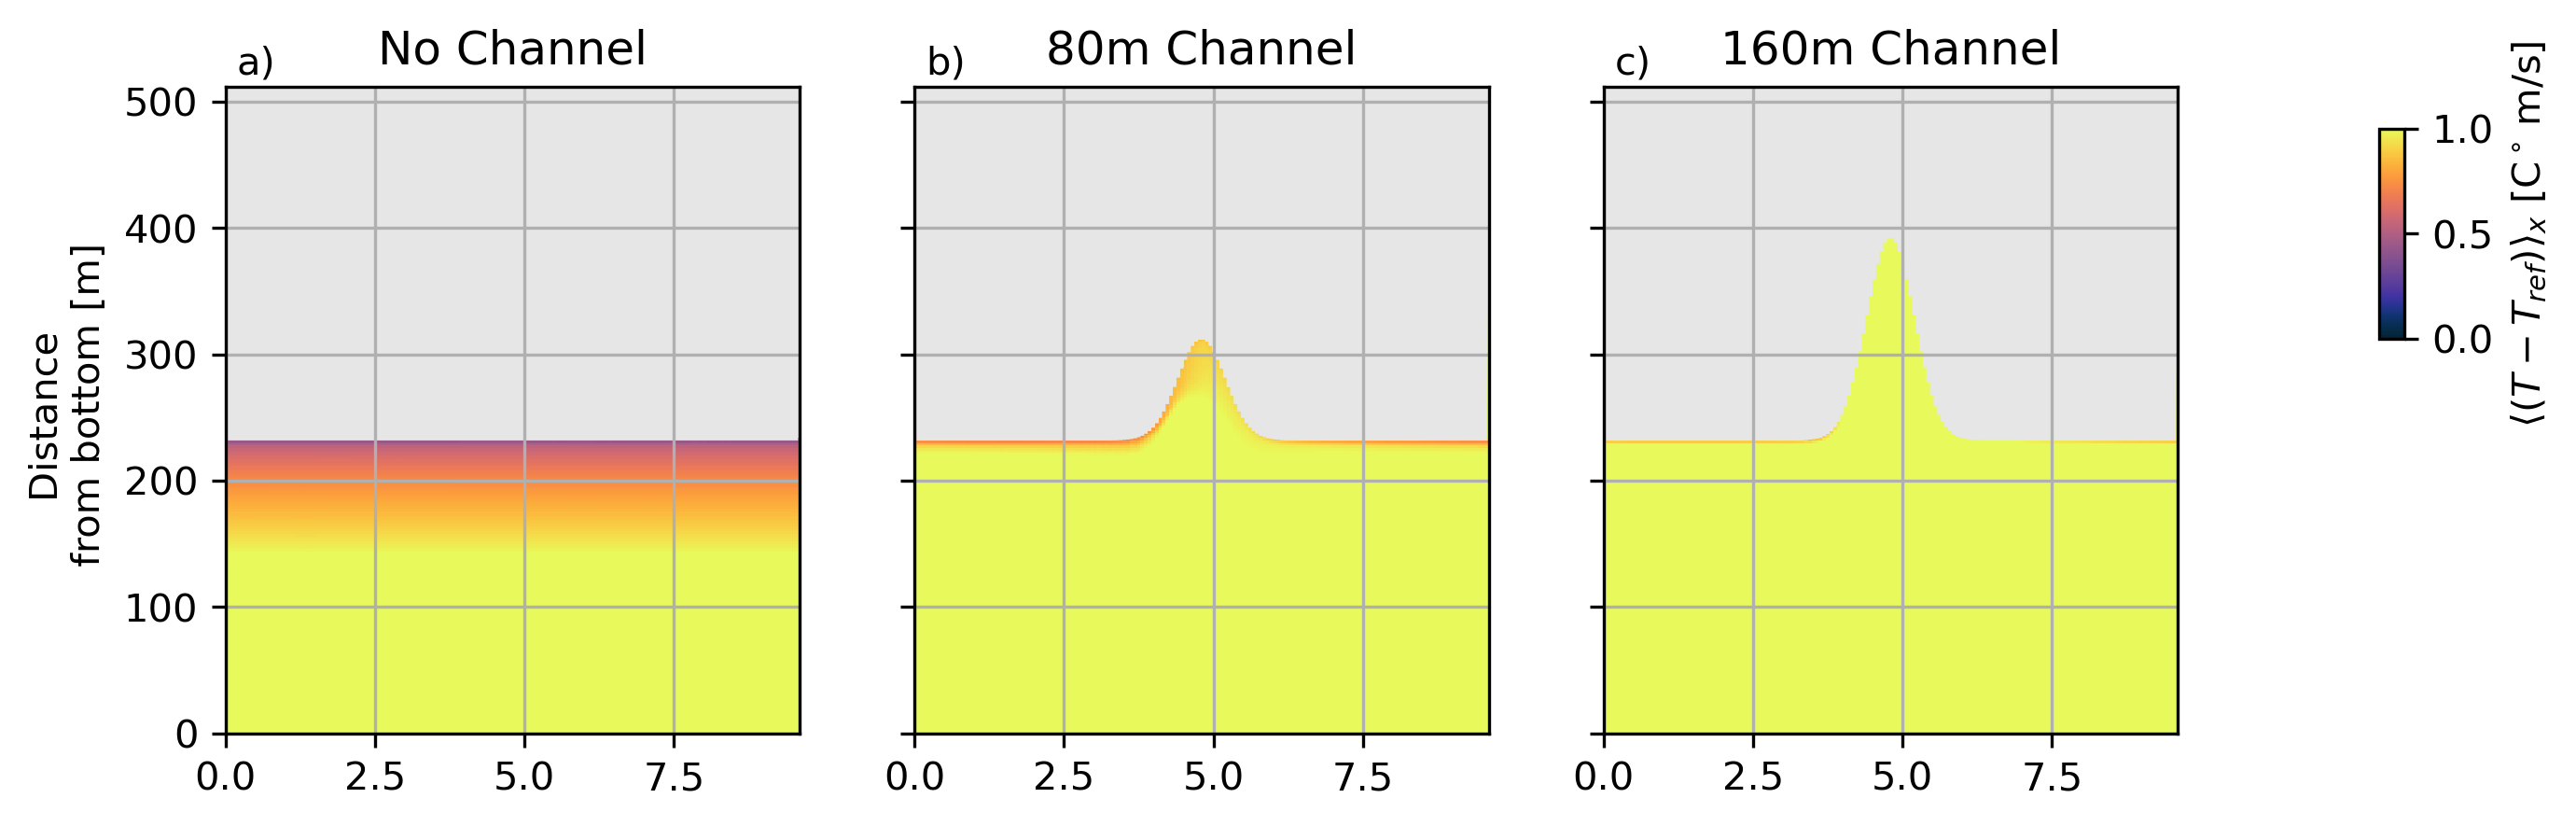

In [23]:
# ADVx_Vm_shift.ADVx_Vm_c120m_Td2_vshift24_dz4
# ADVy_Vm_shift.ADVy_Vm_c120m_Td2_vshift24_dz4
# ADVrE_Vm_shift.ADVrE_Vm_c120m_Td2_vshift24_dz4

fig,ax = plt.subplots(1,3,figsize=(9,3),dpi=300)

kwargs={ 
    "cmap":cm.cm.thermal,
    "vmin":0,
    "vmax":1,
    "add_colorbar":False,
    "rasterized":True
}

kwargs_ustar={ 
    "cmap":cm.cm.solar,
    "vmin":0.01,
    "vmax":0.05,
}


cbar1 = Tanom_shift.Tanom_c0m_Td2_vshift48_dz2.mean(("XC")).plot(x="YC",ax=ax[0],**kwargs)

Tanom_shift.Tanom_c80m_Td2_vshift48_dz2.mean(("XC")).plot(x="YC",ax=ax[1],**kwargs)

Tanom_shift.Tanom_c160m_Td2_vshift48_dz2.mean(("XC")).plot(x="YC",ax=ax[2],**kwargs)


grid = grids["c80m_Td2_vshift48_dz2"]


plot_hfacc_surf_shifted(ax[0],
                         Tanom_shift.hFacC_c0m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"Z_dz2":"Z"}),
                         2,z_shift=-512)
plot_hfacc_surf_shifted(ax[1],
                         Tanom_shift.hFacC_c80m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"Z_dz2":"Z"}),
                         2,z_shift=-512)
plot_hfacc_surf_shifted(ax[2],
                         Tanom_shift.hFacC_c160m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"Z_dz2":"Z"}),
                         2,z_shift=-512)

########################################################################
########################################################################
########################################################################

ticklocations = [-512,-412,-312,-212,-112,-12]
[a.yaxis.set_ticks(ticklocations) for a in ax[:]]
ticklabels = [0,100,200,300,400,500]
[a.set_yticklabels(ticklabels) for a in ax[:]]

[a.yaxis.set_ticklabels([]) for a in ax[1:].ravel()]

[a.set_ylabel("") for a in ax.ravel()]
[a.set_xlabel("") for a in ax.ravel()]
[a.grid() for a in ax.ravel()]
[a.set_xlim(0,9.6) for a in ax.ravel()]

[a.set_title("") for a in ax.ravel()]

ax[0].set_ylabel("Distance \n from bottom [m]")

ax[0].text(0.02, 1.02, "a)", fontsize=10, transform=ax[0].transAxes)
ax[1].text(0.02, 1.02, "b)", fontsize=10, transform=ax[1].transAxes)
ax[2].text(0.02, 1.02, "c)", fontsize=10, transform=ax[2].transAxes)

ax[0].set_title("No Channel")
ax[1].set_title("80m Channel")
ax[2].set_title("160m Channel")

cbar_ax = fig.add_axes([0.98, 0.58, 0.01, 0.25])
fig.colorbar(cbar1, cax =cbar_ax)
cbar_ax.set_ylabel(r"$\left<(T-T_{ref})\right>_{x}$ [C$^\circ\,\mathrm{m/s}$]")
cbar_ax.yaxis.set_tick_params(labelsize=10)

for a in ax[:]:
    a.plot(np.ones(2)*wT_ds_shift.YC[80].values,[0,512],linestyle='--',color='k',linewidth=1)


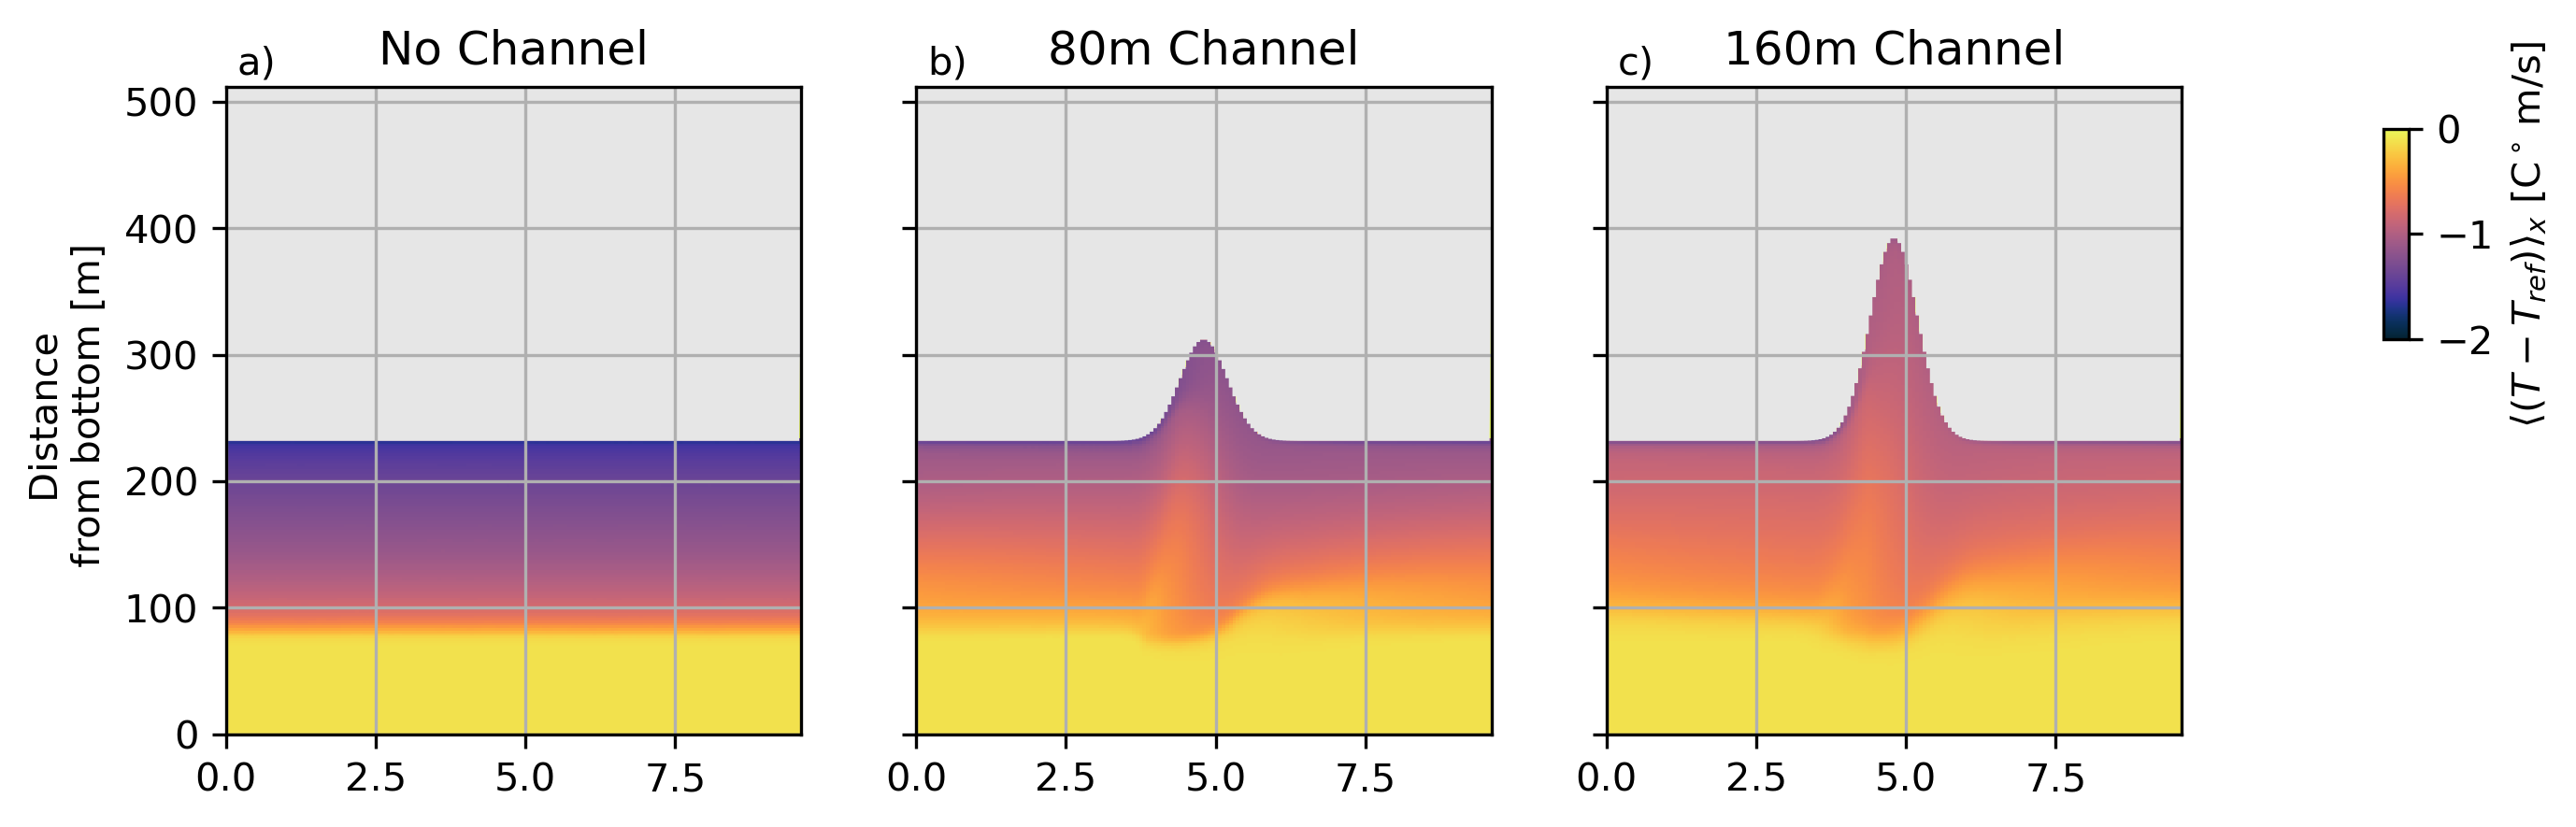

In [24]:
# ADVx_Vm_shift.ADVx_Vm_c120m_Td2_vshift24_dz4
# ADVy_Vm_shift.ADVy_Vm_c120m_Td2_vshift24_dz4
# ADVrE_Vm_shift.ADVrE_Vm_c120m_Td2_vshift24_dz4

fig,ax = plt.subplots(1,3,figsize=(9,3),dpi=300)

kwargs={ 
    "cmap":cm.cm.thermal,
    "vmin":-2,
    "vmax":0,
    "add_colorbar":False,
    "rasterized":True
}

kwargs_ustar={ 
    "cmap":cm.cm.solar,
    "vmin":0.01,
    "vmax":0.05,
}


cbar1 = temp_shift.THETA_c0m_Td2_vshift48_dz2.mean(("XC")).plot(x="YC",ax=ax[0],**kwargs)

temp_shift.THETA_c80m_Td2_vshift48_dz2.mean(("XC")).plot(x="YC",ax=ax[1],**kwargs)

temp_shift.THETA_c160m_Td2_vshift48_dz2.mean(("XC")).plot(x="YC",ax=ax[2],**kwargs)


grid = grids["c80m_Td2_vshift48_dz2"]


plot_hfacc_surf_shifted(ax[0],
                         temp_shift.hFacC_c0m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"Z_dz2":"Z"}),
                         2,z_shift=-512)
plot_hfacc_surf_shifted(ax[1],
                         temp_shift.hFacC_c80m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"Z_dz2":"Z"}),
                         2,z_shift=-512)
plot_hfacc_surf_shifted(ax[2],
                         temp_shift.hFacC_c160m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"Z_dz2":"Z"}),
                         2,z_shift=-512)

########################################################################
########################################################################
########################################################################

ticklocations = [-512,-412,-312,-212,-112,-12]
[a.yaxis.set_ticks(ticklocations) for a in ax[:]]
ticklabels = [0,100,200,300,400,500]
[a.set_yticklabels(ticklabels) for a in ax[:]]

[a.yaxis.set_ticklabels([]) for a in ax[1:].ravel()]

[a.set_ylabel("") for a in ax.ravel()]
[a.set_xlabel("") for a in ax.ravel()]
[a.grid() for a in ax.ravel()]
[a.set_xlim(0,9.6) for a in ax.ravel()]

[a.set_title("") for a in ax.ravel()]

ax[0].set_ylabel("Distance \n from bottom [m]")

ax[0].text(0.02, 1.02, "a)", fontsize=10, transform=ax[0].transAxes)
ax[1].text(0.02, 1.02, "b)", fontsize=10, transform=ax[1].transAxes)
ax[2].text(0.02, 1.02, "c)", fontsize=10, transform=ax[2].transAxes)

ax[0].set_title("No Channel")
ax[1].set_title("80m Channel")
ax[2].set_title("160m Channel")

cbar_ax = fig.add_axes([0.98, 0.58, 0.01, 0.25])
fig.colorbar(cbar1, cax =cbar_ax)
cbar_ax.set_ylabel(r"$\left<(T-T_{ref})\right>_{x}$ [C$^\circ\,\mathrm{m/s}$]")
cbar_ax.yaxis.set_tick_params(labelsize=10)

for a in ax[:]:
    a.plot(np.ones(2)*wT_ds_shift.YC[80].values,[0,512],linestyle='--',color='k',linewidth=1)
